In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib

data_dir = '../data'
for file in os.listdir(data_dir):
    if os.path.isdir(file):
        continue
    print(file)

df.pkl
soil
phenology_features.pkl
ndvi
polygons
PRISM
plot_elev_features.pkl
DEM


In [2]:
df_path = os.path.join(data_dir, 'df.pkl')
df = pd.read_pickle(df_path)

df

,plot_id,curve_mean,curve_min,curve_max,pro_curve_mean,pro_curve_min,pro_curve_max,plan_curve_mean,plan_curve_min,plan_curve_max,...,fraggt10_r,wthirdbar_r,wtenthbar_r,wfifteenbar_r,wsatiated_r,profile_depth,max_depth,drain_ord,restrictiondepth_cm,dominant_mukey
0,0,0.000489,-0.009361,0.013225,0.000620,-0.010633,0.013191,0.000489,-0.009361,0.013225,...,0.984375,7.171875,11.750000,1.514063,29.875000,106.117647,106.117647,1.0,37.647059,69511
1,0,0.000489,-0.009361,0.013225,0.000620,-0.010633,0.013191,0.000489,-0.009361,0.013225,...,0.984375,7.171875,11.750000,1.514063,29.875000,106.117647,106.117647,1.0,37.647059,69511
2,0,0.000489,-0.009361,0.013225,0.000620,-0.010633,0.013191,0.000489,-0.009361,0.013225,...,0.984375,7.171875,11.750000,1.514063,29.875000,106.117647,106.117647,1.0,37.647059,69511
3,0,0.000489,-0.009361,0.013225,0.000620,-0.010633,0.013191,0.000489,-0.009361,0.013225,...,0.984375,7.171875,11.750000,1.514063,29.875000,106.117647,106.117647,1.0,37.647059,69511
4,0,0.000489,-0.009361,0.013225,0.000620,-0.010633,0.013191,0.000489,-0.009361,0.013225,...,0.984375,7.171875,11.750000,1.514063,29.875000,106.117647,106.117647,1.0,37.647059,69511
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35975,3597,-0.000758,-0.019660,0.016977,0.001952,-0.012836,0.017013,-0.000758,-0.019660,0.016977,...,0.000000,11.390789,17.290789,3.045395,37.302632,152.000000,152.000000,1.0,NaN,69569
35976,3597,-0.000758,-0.019660,0.016977,0.001952,-0.012836,0.017013,-0.000758,-0.019660,0.016977,...,0.000000,11.390789,17.290789,3.045395,37.302632,152.000000,152.000000,1.0,NaN,69569
35977,3597,-0.000758,-0.019660,0.016977,0.001952,-0.012836,0.017013,-0.000758,-0.019660,0.016977,...,0.000000,11.390789,17.290789,3.045395,37.302632,152.000000,152.000000,1.0,NaN,69569
35978,3597,-0.000758,-0.019660,0.016977,0.001952,-0.012836,0.017013,-0.000758,-0.019660,0.016977,...,0.000000,11.390789,17.290789,3.045395,37.302632,152.000000,152.000000,1.0,NaN,69569


In [3]:
# --- Leakage exclusion (Option A) ---
# Remove anything contemporaneous with or derived from the harvest window (weeks 36–43):
#   - ndvi_smooth_mean for weeks 36–44 (direct NDVI values during target window)
#   - ndvi_smooth_slope / ndvi_smooth_std for weeks 36+ (same-window phenology)
#   - whole-season NDVI summary stats that embed harvest-season signal:
#       ndvi_mean, ndvi_cov, ndvi_std, ndvi_mean_norm, ndvi_std_norm, ndvi_cov_norm, health
#
# KEPT: ndvi_smooth_slope/std for weeks 1–35 (early-season leading indicators,
#        temporally prior to targets — valid forward-looking predictors)

leakage_cols = []

# 1. Raw NDVI means for target and adjacent weeks
leakage_cols += [col for col in df.columns
                 if col.startswith('ndvi_smooth_mean') and any(
                     col.endswith(f'_{m}') for m in range(36, 45)
                 )]

# 2. All other ndvi_smooth_mean cols (non-target season)
leakage_cols += [col for col in df.columns
                 if col.startswith('ndvi_smooth_mean') and col not in leakage_cols]

# 3. Harvest-window slope and std (weeks 36+)
leakage_cols += [col for col in df.columns
                 if (col.startswith('ndvi_smooth_slope_') or col.startswith('ndvi_smooth_std_'))
                 and int(col.rsplit('_', 1)[-1]) >= 36]

# 4. Whole-season NDVI summaries (time-varying; embed harvest signal)
leakage_cols += [c for c in ['ndvi_mean', 'ndvi_cov', 'ndvi_std',
                              'ndvi_mean_norm', 'ndvi_std_norm', 'ndvi_cov_norm',
                              'health']
                 if c in df.columns]

# 5. Spectral indices that correlate with chlorophyll/harvest quality
leakage_cols += [col for col in df.columns if 'mcari2' in col or 'rendvi' in col]

# 6. Geometry artifacts
leakage_cols += [col for col in df.columns if col.endswith('length')]

In [4]:
# --- NDVI anomaly targets: spatial deviation from vineyard mean ---
# Isolates terroir signal; vintage effects have been removed
target_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]

drop_cols = leakage_cols + ['plot_id', 'year'] + target_cols
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_cols]

print(f'Samples: {len(X)}  |  Features: {X.shape[1]}  |  Targets: {len(target_cols)}')
print(f'Anomaly mean: {y.mean().mean():.6f}  (should be ~0)')
print(f'Anomaly std:  {y.std().mean():.4f}')


Samples: 35980  |  Features: 283  |  Targets: 8
Anomaly mean: 0.000000  (should be ~0)
Anomaly std:  0.0927


In [5]:
from sklearn.model_selection import train_test_split

# Spatial model: random split is appropriate — we're learning place not time
X_train, X_tune, y_train, y_tune = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Year-stratified test set to check that model generalises across vintages
X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

print(f'Train: {X_train.shape}')
print(f'Tune:  {X_tune.shape}')
print(f'Test:  {X_test.shape}')


Train: (24466, 283)
Tune:  (7196, 283)
Test:  (4318, 283)


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


numeric_features = X_train.select_dtypes(include=['float64', 'int64']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    StackingRegressor
)
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor

from xgboost import XGBRegressor

In [8]:
base_models = [
    ('rf', RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=8274, n_jobs=-1
    )),
    ('et', ExtraTreesRegressor(
        n_estimators=300, max_depth=12, random_state=836409, n_jobs=-1
    )),
    ('gb', GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.05, max_depth=8, random_state=13425
    )),
    ('xgb', XGBRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        subsample=0.5, colsample_bytree=0.5, random_state=4111112, n_jobs=-1
    )),
    ('knn', KNeighborsRegressor(n_neighbors=8, weights='distance', n_jobs=-1))
]

In [9]:
meta_model = ElasticNetCV(
    l1_ratio=[0.1, 0.5, 0.9],
    alphas=np.logspace(-2, 1, 10),  
    cv=5,
    max_iter=20000,
    n_jobs=-1
)

In [10]:
stacked_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    passthrough=True,
    cv=5,
    n_jobs=-1
)

In [11]:
multi_output_model = MultiOutputRegressor(stacked_model, n_jobs=-1)

In [12]:
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('regressor', TransformedTargetRegressor(
        regressor=multi_output_model,
        transformer=StandardScaler()  
    ))
])

In [13]:
model_path = 'models/tree_ensemble.pkl'
if not os.path.isfile(model_path):
    model_pipeline.fit(X_train, y_train)
    joblib.dump(model_pipeline, model_path)
else:
    model_pipeline = joblib.load(model_path)

In [14]:
y_pred_tune = model_pipeline.predict(X_tune)
y_pred_tune.shape

(7196, 8)

In [15]:
y_pred_train = model_pipeline.predict(X_train)
y_pred_train.shape

(24466, 8)

In [16]:
from sklearn.metrics import mean_squared_error, r2_score


print("Tune Stacked Ensemble R2:", r2_score(y_tune, y_pred_tune))
print("Tune Stacked Ensemble RMSE:", mean_squared_error(y_tune, y_pred_tune))



print("Train Stacked Ensemble R2:", r2_score(y_train, y_pred_train))
print("Train Stacked Ensemble RMSE:", mean_squared_error(y_train, y_pred_train))

Tune Stacked Ensemble R2: 0.9332802152514954
Tune Stacked Ensemble RMSE: 0.0005375705190975388
Train Stacked Ensemble R2: 0.9845836445229241
Train Stacked Ensemble RMSE: 0.00012841996777254182


In [17]:
# Test set ground truth
y_true = y_test.to_numpy()


In [18]:
y_true =y_test.to_numpy()

In [19]:
y_pred = model_pipeline.predict(X_test)

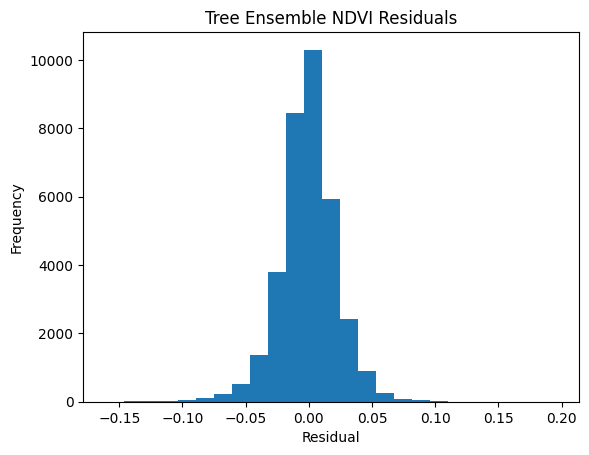

In [20]:
plt.hist(y_pred.flatten() - y_true.flatten(), bins = 25)
plt.title('Tree Ensemble NDVI Residuals')
plt.ylabel('Frequency')
plt.xlabel('Residual')
plt.savefig('regression_resid_hist.png')
plt.show()

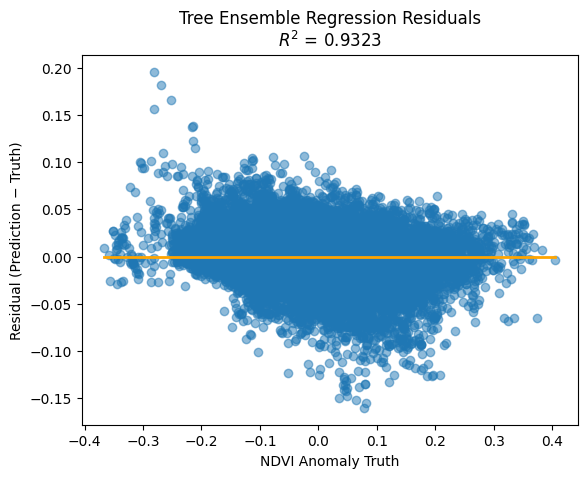

In [21]:
plt.scatter(y_true.flatten(), y_pred.flatten() - y_true.flatten(), alpha=0.5)
plt.plot(
    [y_true.flatten().min(), y_true.flatten().max()],
    [0, 0],
    c='orange',
    linewidth=2,
)

plt.xlabel('NDVI Anomaly Truth')
plt.ylabel('Residual (Prediction − Truth)')
plt.title(f'Tree Ensemble Regression Residuals\n$R^2$ = {np.round(r2_score(y_true, y_pred), 4)}')
plt.savefig('../img/regression_resid.png')
plt.show()

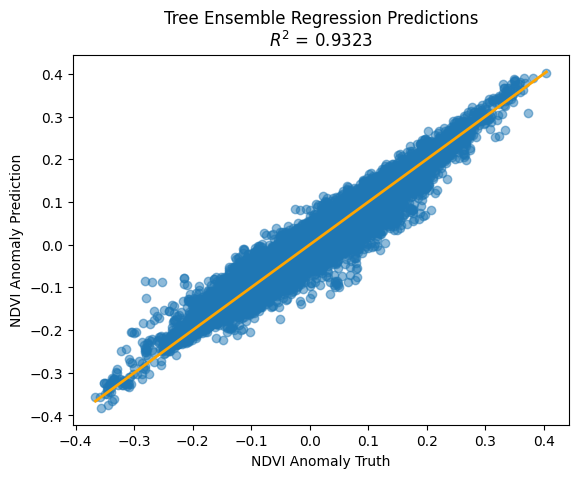

In [22]:
plt.scatter(y_true.flatten(), y_pred.flatten(), alpha=0.5)
plt.plot(
    [y_true.flatten().min(), y_true.flatten().max()],
    [y_true.flatten().min(), y_true.flatten().max()],
    c='orange',
    linewidth=2,
)

plt.xlabel('NDVI Anomaly Truth')
plt.ylabel('NDVI Anomaly Prediction')
plt.title(f'Tree Ensemble Regression Predictions\n$R^2$ = {np.round(r2_score(y_true, y_pred), 4)}')
plt.savefig('../img/regression_results.png')
plt.show()

In [23]:
weeks = range(36, 44)  # NDVI weeks
n_weeks = len(weeks)

In [24]:
cmap = plt.colormaps['coolwarm_r'].resampled(n_weeks)
norm = plt.Normalize(vmin=0, vmax=n_weeks - 1)

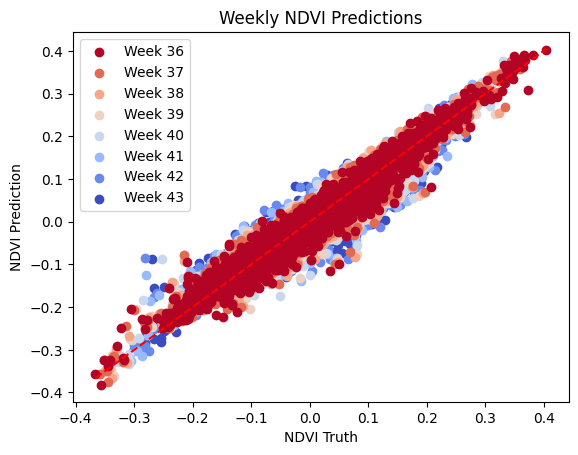

In [25]:
for i, week in reversed(list(enumerate(weeks))):
    # print(week)
    plt.scatter(
        y_true[:,i],
        y_pred[:,i], 
        label = f'Week {36 + i}', 
        alpha = 1,
        color = cmap(norm(i))
    )
    # plt.show()
    
plt.plot(
    (y_true.min().min(), y_true.max().max()),
    (y_true.min().min(), y_true.max().max()),
    '--r'
)
handles, labels = plt.gca().get_legend_handles_labels()

# Reverse them so Week 36, 37, ... are ascending again
handles = handles[::-1]
labels = labels[::-1]

plt.legend(handles, labels)
plt.title('Weekly NDVI Predictions')
plt.xlabel('NDVI Truth')
plt.ylabel('NDVI Prediction')
plt.savefig('../img/weekly_preds.png')

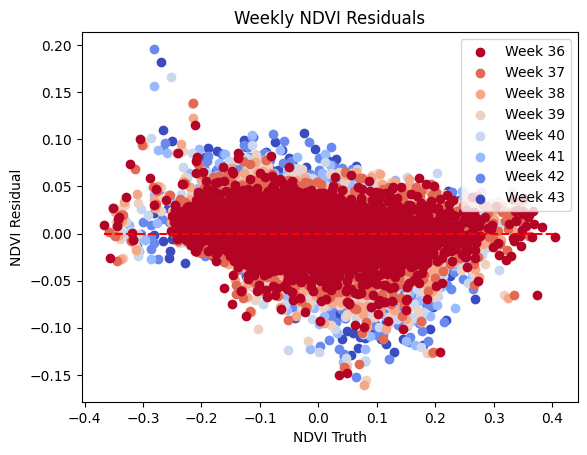

In [26]:
for i, week in reversed(list(enumerate(weeks))):
    # print(week)
    plt.scatter(
        y_true[:,i],
        y_pred[:,i] - y_true[:,i], 
        label = f'Week {36 + i}', 
        alpha = 1,
        color = cmap(norm(i))
    )
    # plt.show()
    
plt.plot(
    (y_true.min().min(), y_true.max().max()),
    (0, 0),
    '--r'
)
handles, labels = plt.gca().get_legend_handles_labels()

# Reverse them so Week 36, 37, ... are ascending again
handles = handles[::-1]
labels = labels[::-1]

plt.legend(handles, labels)
plt.title('Weekly NDVI Residuals')
plt.xlabel('NDVI Truth')
plt.ylabel('NDVI Residual')
plt.savefig('../img/weekly_preds_resid.png')

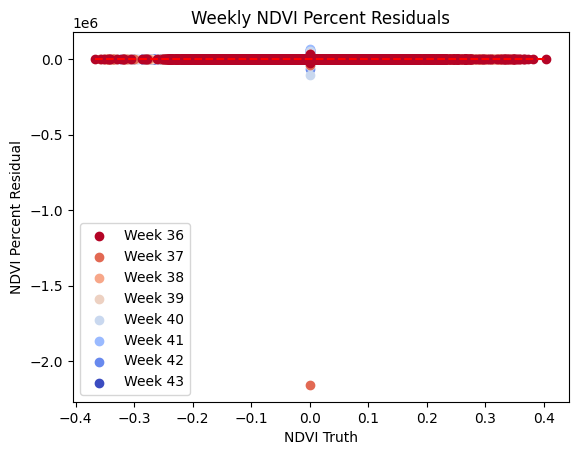

In [27]:
for i, week in reversed(list(enumerate(weeks))):
    # print(week)
    plt.scatter(
        y_true[:,i],
        (y_pred[:,i] - y_true[:,i]) / y_true[:,i] * 100, 
        label = f'Week {36 + i}', 
        alpha = 1,
        color = cmap(norm(i))
    )
    # plt.show()
    
plt.plot(
    (y_true.min().min(), y_true.max().max()),
    (0, 0),
    '--r'
)
handles, labels = plt.gca().get_legend_handles_labels()

# Reverse them so Week 36, 37, ... are ascending again
handles = handles[::-1]
labels = labels[::-1]

plt.legend(handles, labels)
plt.title('Weekly NDVI Percent Residuals')
plt.xlabel('NDVI Truth')
plt.ylabel('NDVI Percent Residual')
plt.savefig('../img/weekly_pct_preds_resid.png')

## Test Set Evaluation by Week


In [28]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_test = model_pipeline.predict(X_test)

print('=== Test Set (held-out plots) ===')
print(f'  R²  : {r2_score(y_test, y_pred_test):.4f}')
print(f'  RMSE: {mean_squared_error(y_test, y_pred_test)**.5:.6f}')
print()
print('=== Per-week R² ===')
for i, w in enumerate(range(36, 44)):
    wr2 = r2_score(y_test.iloc[:, i], y_pred_test[:, i])
    print(f'  Week {w}: {wr2:.4f}')
print()
print('=== In-sample comparison ===')
print(f'  Tune R²  : {r2_score(y_tune, y_pred_tune):.4f}')
print(f'  Train R² : {r2_score(y_train, y_pred_train):.4f}')


=== Test Set (held-out plots) ===
  R²  : 0.9323
  RMSE: 0.022860

=== Per-week R² ===
  Week 36: 0.9612
  Week 37: 0.9583
  Week 38: 0.9538
  Week 39: 0.9471
  Week 40: 0.9352
  Week 41: 0.9218
  Week 42: 0.8986
  Week 43: 0.8828

=== In-sample comparison ===
  Tune R²  : 0.9333
  Train R² : 0.9846


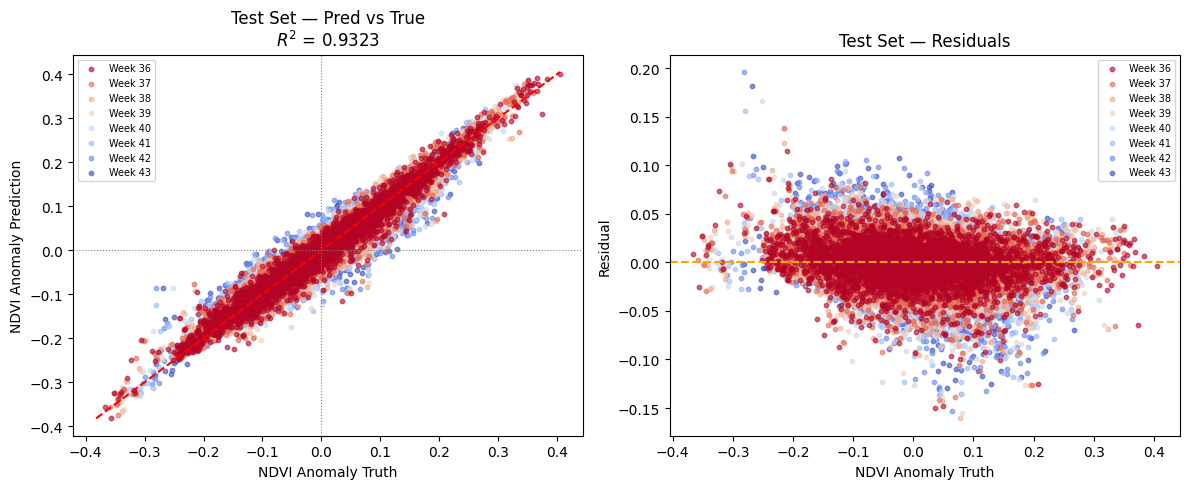

In [29]:
cmap_t = plt.colormaps['coolwarm_r'].resampled(len(target_cols))
norm_t = plt.Normalize(vmin=0, vmax=len(target_cols) - 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for j in range(len(target_cols) - 1, -1, -1):
    ax.scatter(y_true[:, j], y_pred_test[:, j],
               label=f'Week {36 + j}', alpha=0.6,
               color=cmap_t(norm_t(j)), s=10)
lims = [min(y_true.min(), y_pred_test.min()),
        max(y_true.max(), y_pred_test.max())]
ax.plot(lims, lims, '--r', linewidth=1.5)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('NDVI Anomaly Truth')
ax.set_ylabel('NDVI Anomaly Prediction')
ax.set_title(f'Test Set — Pred vs True\n$R^2$ = {r2_score(y_test, y_pred_test):.4f}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=7)

ax = axes[1]
for j in range(len(target_cols) - 1, -1, -1):
    ax.scatter(y_true[:, j], y_pred_test[:, j] - y_true[:, j],
               label=f'Week {36 + j}', alpha=0.6,
               color=cmap_t(norm_t(j)), s=10)
ax.axhline(0, color='orange', linewidth=1.5, linestyle='--')
ax.set_xlabel('NDVI Anomaly Truth')
ax.set_ylabel('Residual')
ax.set_title('Test Set — Residuals')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=7)

plt.tight_layout()
plt.savefig('../img/anomaly_test_validation.png', dpi=150, bbox_inches='tight')
plt.show()